### **HAPLOTYPE CLUSTERING WITH PHENOTYPE DATA**

This workflow performs PCA and hierarchical clustering using interval-specific variation data. It retains the exploratory dendrogram-cut analysis, alternative PCA projections, 3D PCA, interval-level assignment tables, and cross-interval combination from the original workflow.

In the PCA plots, **point colour represents phenotype** and **point shape represents the inferred haplotype**. In the final dendrogram, branch colour represents haplotype membership and leaf-label colour represents phenotype.

In [1]:
import os
import re
from datetime import date
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial import ConvexHull, QhullError
from matplotlib.patches import Polygon, Ellipse

###### =============================================================================
##### INPUT DIRECTORY AND FILE SELECTION
###### =============================================================================

In [2]:
# Directory containing the interval-specific Excel files.
workDir="/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis"
datDir = f"{workDir}/extractedTraitIntervalTables/"

# List all Excel files in the directory.
files = sorted(
    [
        f for f in os.listdir(datDir)
        if f.endswith(".xlsx") and not f.startswith("~$")
    ]
)

In [3]:
# Display the available files and their corresponding indices.
for file_index, filename in enumerate(files):
    print(f"{file_index}: {filename}")

0: Dabbi_dth_2B_7719365_7814565_IBSpy_7700000_7850000.xlsx
1: Dabbi_dth_6A_19773127_19961633_IBSpy_19750000_20000000.xlsx
2: Dabbi_dth_8B_7925057_8153073_IBSpy_7900000_8200000.xlsx
3: Dabbi_dth_9A_6126196_6263250_IBSpy_6100000_6300000.xlsx
4: Dabbi_panLen_1A_6416669_6933524_IBSpy_6400000_6950000.xlsx
5: Dabbi_panLen_2A_4433713_4675660_IBSpy_4400000_4700000.xlsx
6: Dabbi_panLen_2B_25700018_25795218_IBSpy_25700000_25800000.xlsx
7: Dabbi_panLen_3A_4129008_4227350_IBSpy_4100000_4250000.xlsx
8: Dabbi_panLen_3B_2638730_2806858_IBSpy_2600000_2850000.xlsx
9: Dabbi_panLen_4A_7106186_7277839_IBSpy_7100000_7300000.xlsx
10: Dabbi_panLen_6B_7763900_8051348_IBSpy_7750000_8100000.xlsx
11: Dabbi_panLen_7B_1903398_2121900_IBSpy_1900000_2150000.xlsx
12: Dabbi_panShap_10A_2479547_2604219_IBSpy_2450000_2650000.xlsx
13: Dabbi_panShap_1B_23249295_23355755_IBSpy_23200000_23400000.xlsx
14: Dabbi_panShap_2A_24741867_25141867_IBSpy_24700000_25150000.xlsx
15: Dabbi_panShap_2A_24824087_25059647_IBSpy_24800000_251

In [235]:
# Select one file for analysis.
idx = 57
f = files[idx]

filepath = os.path.join(datDir, f)
INPUT_FILE = filepath

#### EXTRACT METADATA FROM THE FILENAME

Expected filename structure:

`reference_trait_chromosome_start_end.xlsx`

The pattern also accepts filenames containing rounded IBSpy coordinates:

`reference_trait_chromosome_start_end_IBSpy_roundedStart_roundedEnd.xlsx`

In [236]:
match = re.match(
    r"(?P<genome>[^_]+)_"
    r"(?P<trait>[^_]+)_"
    r"(?P<chromosome>[A-Za-z0-9]+)_"
    r"(?P<start>\d+)_"
    r"(?P<end>\d+)"
    r"(?:_IBSpy_(?P<rounded_start>\d+)_(?P<rounded_end>\d+))?"
    r"(?:_duplicate\d+)?"
    r"\.xlsx$",
    f
)

if not match:
    raise ValueError(
        "Filename does not match the expected structure: "
        "reference_trait_chromosome_start_end.xlsx"
    )

genome = match.group("genome")
trait = match.group("trait")
chromosome = match.group("chromosome")
start_pos = int(match.group("start"))
end_pos = int(match.group("end"))

# Retrieve rounded IBSpy coordinates when they are included in the filename.
rounded_start = match.group("rounded_start")
rounded_end = match.group("rounded_end")

if rounded_start is not None and rounded_end is not None:
    analysis_start = int(rounded_start)
    analysis_end = int(rounded_end)
else:
    analysis_start = start_pos
    analysis_end = end_pos

print(f"\nProcessing file: {f}")
print(f"File path: {filepath}")
print(f"Reference genome: {genome}")
print(f"Trait: {trait}")
print(f"Chromosome: {chromosome}")
print(f"Original interval: {start_pos:,}-{end_pos:,} bp")
print(f"Analysed interval: {analysis_start:,}-{analysis_end:,} bp")


Processing file: Quncho_seedColor_9B_1479311_1599456_IBSpy_1450000_1600000.xlsx
File path: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/extractedTraitIntervalTables/Quncho_seedColor_9B_1479311_1599456_IBSpy_1450000_1600000.xlsx
Reference genome: Quncho
Trait: seedColor
Chromosome: 9B
Original interval: 1,479,311-1,599,456 bp
Analysed interval: 1,450,000-1,600,000 bp


In [238]:
# Create an interval-specific directory for output tables and figures.
outDir = os.path.join(
    workDir,
    f"{genome}/{genome}-{trait}-{chromosome}-{start_pos}-{end_pos}-Pheno"
)

os.makedirs(outDir, exist_ok=True)

print(f"Output directory: {outDir}")

Output directory: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-9B-1479311-1599456-Pheno


In [240]:
# =============================================================================
# FIGURE AND ANALYSIS LABELS
# =============================================================================

analysis_date = date.today()

target = (
    f"{analysis_start / 1e6:.2f}-"
    f"{analysis_end / 1e6:.2f}Mb"
)

###### =============================================================================
##### PHENOTYPE DATA AND VISUAL ENCODING
###### =============================================================================

Phenotypes are supplied as an accession-to-phenotype dictionary. This dictionary can be updated if accessions or phenotype categories change. Accessions that are not present in the dictionary are retained and assigned the phenotype `unknown`.

Across the PCA figures:

- **colour = phenotype**
- **shape = inferred haplotype**

In [241]:
# Path to the CSV file containing phenotype information
phenotype_file = os.path.join(
    workDir,
    "2026-Aug-13_eiar_consFieldGrainColorBinary_v2.csv"
)

In [242]:
# Read the phenotype table
phenotype_df = pd.read_csv(phenotype_file)

# Standardise column names
phenotype_df.columns = (
    phenotype_df.columns
    .astype(str)
    .str.strip()
)

# Check that the required columns are present
required_columns = {"Name", "color"}
missing_columns = required_columns.difference(phenotype_df.columns)

if missing_columns:
    raise ValueError(
        f"Phenotype file is missing columns: {sorted(missing_columns)}"
    )

# Standardise accession names and phenotype values
phenotype_df["Name"] = (
    phenotype_df["Name"]
    .astype(str)
    .str.strip()
)

phenotype_df["color"] = (
    phenotype_df["color"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

# Remove rows without an accession name or phenotype
phenotype_df = phenotype_df.dropna(
    subset=["Name", "color"]
)

# Check whether an accession has conflicting phenotype values
conflicting_phenotypes = (
    phenotype_df
    .groupby("Name")["color"]
    .nunique()
)

conflicting_phenotypes = conflicting_phenotypes[
    conflicting_phenotypes > 1
]

if not conflicting_phenotypes.empty:
    raise ValueError(
        "Conflicting phenotype values were found for: "
        + ", ".join(conflicting_phenotypes.index)
    )

# Remove any repeated identical records
phenotype_df = phenotype_df.drop_duplicates(
    subset="Name",
    keep="first"
)

# Create the accession-to-phenotype dictionary
PHENOTYPE = dict(
    zip(
        phenotype_df["Name"],
        phenotype_df["color"]
    )
)

print(f"Loaded phenotypes for {len(PHENOTYPE)} accessions.")
print(PHENOTYPE)

Loaded phenotypes for 177 accessions.
{'T-33': 'White', 'T366': 'White', 'T379': 'White', 'T304': 'Brown', 'T116': 'Brown', 'T297': 'Brown', 'T87': 'White', 'T288': 'Brown', 'T345': 'Brown', 'T224': 'White', 'T283': 'White', 'T365': 'White', 'T412': 'Brown', 'T330': 'White', 'T132': 'Brown', 'T206': 'White', 'T99': 'White', 'T336': 'Brown', 'T404': 'Brown', 'T177': 'White', 'Quncho': 'White', 'Boni': 'White', 'Dtt2-02': 'White', 'Dabbi': 'Brown', 'addisie': 'White', 'karadebi': 'Brown', 'DZ': 'White', 'teff_1': 'Brown', 'teff_10': 'White', 'teff_100': 'Brown', 'teff_102': 'White', 'teff_103': 'White', 'teff_104': 'White', 'teff_106': 'Brown', 'teff_107': 'White', 'teff_109': 'White', 'teff_111': 'White', 'teff_112': 'White', 'teff_113': 'Brown', 'teff_115': 'Brown', 'teff_117': 'Brown', 'teff_118': 'White', 'teff_120': 'White', 'teff_122': 'White', 'teff_123': 'White', 'teff_128': 'White', 'teff_129': 'White', 'teff_130': 'White', 'teff_131': 'Brown', 'teff_133': 'White', 'teff_135': '

In [243]:

# Point colours are based on the phenotype-enabled workflow. Black marker
# edges ensure that the cream colour used for the White phenotype remains
# visible against a white plotting background.
phenotype_to_color = {
    "White": "#FFFDD0",
    "Brown": "saddlebrown",
    "unknown": "#DA70D6",
}

# Darker colours are used for dendrogram text so that every leaf label remains
# legible on a white background while representing the same phenotype classes.
phenotype_to_label_color = {
    "White": "#DAA520",
    "Brown": "#A52A2A",
    "unknown": "#DA70D6",
}

phenotype_order = ["White", "Brown", "unknown"]

# Marker shapes are assigned to threshold-derived haplotypes later in the
# workflow. If more haplotypes are inferred than there are marker shapes, the
# marker sequence is reused and a warning is printed.
haplotype_markers = [
    "o", "^", "*", "s", "v", "D", "P", "X", "<", ">", "h", "p", "8", "d", "H"
]

In [244]:
# =============================================================================
# LOAD THE VARIATION DATA AND ATTACH PHENOTYPES
#
# The first column is expected to contain accession identifiers. All remaining
# input columns should contain numeric variation measurements for the interval.
# =============================================================================

df = pd.read_excel(INPUT_FILE)

# Use the first column as the accession identifier.
df = df.set_index(df.columns[0])

# Ensure accession identifiers are strings and remove accidental whitespace.
df.index = df.index.astype(str).str.strip()

# Confirm that accession names are unique.
if not df.index.is_unique:
    duplicated_accessions = df.index[df.index.duplicated()].unique()

    raise ValueError(
        "Duplicate accession identifiers were detected: "
        + ", ".join(duplicated_accessions)
    )

# Attach phenotype information by accession name. Unmapped accessions are
# retained as 'unknown' rather than being discarded from the analysis.
df["phenotype"] = (
    df.index.to_series()
    .map(PHENOTYPE)
    .fillna("unknown")
)

# Convert only the input variation columns to numeric values. Values that
# cannot be converted are represented as missing values.
variation_df = (
    df.drop(columns="phenotype")
    .apply(pd.to_numeric, errors="coerce")
)

print(f"Number of accessions loaded: {variation_df.shape[0]}")
print(f"Number of variation variables loaded: {variation_df.shape[1]}")

print("\nPhenotype counts:")
print(df["phenotype"].value_counts(dropna=False))

unmapped_accessions = df.index[df["phenotype"] == "unknown"].tolist()

if unmapped_accessions:
    print(
        "\nAccessions assigned to the 'unknown' phenotype: "
        + ", ".join(unmapped_accessions)
    )

display(df.head())

Number of accessions loaded: 177
Number of variation variables loaded: 4

Phenotype counts:
White    107
Brown     70
Name: phenotype, dtype: int64


,1450000,1500000,1550000,1600000,phenotype
Name,,,,,
teff_100,4,13,20,15,Brown
teff_102,9,10,6,69,White
teff_103,13,16,19,70,White
teff_104,8,10,9,69,White
teff_106,7,15,21,13,Brown


In [245]:
## check which accession has an unknown phenotype

unknown_accessions = df.index[
    df["phenotype"] == "unknown"
].tolist()

print("Accessions with unknown phenotype:")
print(unknown_accessions)

Accessions with unknown phenotype:
[]


In [246]:
df.loc[df["phenotype"] == "unknown"]

,1450000,1500000,1550000,1600000,phenotype
Name,,,,,


In [247]:
# =============================================================================
# DATA QUALITY CONTROL
# =============================================================================

# Remove columns that contain no numeric observations.
all_missing_columns = variation_df.columns[
    variation_df.isna().all()
]

if len(all_missing_columns) > 0:
    print(
        f"Removing {len(all_missing_columns)} columns containing only "
        "missing values."
    )

    variation_df = variation_df.drop(
        columns=all_missing_columns
    )

# Replace remaining missing values with the median of the corresponding
# variation column.
variation_df = variation_df.fillna(
    variation_df.median()
)

# Remove invariant columns because they contain no information for PCA or
# clustering.
variable_columns = variation_df.columns[
    variation_df.nunique(dropna=False) > 1
]

removed_invariant = (
    variation_df.shape[1] - len(variable_columns)
)

if removed_invariant > 0:
    print(
        f"Removing {removed_invariant} invariant variation columns."
    )

variation_df = variation_df.loc[:, variable_columns]

# Stop the analysis if no informative variation columns remain.
if variation_df.shape[1] == 0:
    raise ValueError(
        "No variable numeric columns remain after data filtering."
    )

# Stop the analysis if fewer than two accessions are available.
if variation_df.shape[0] < 2:
    raise ValueError(
        "At least two accessions are required for clustering."
    )

print(
    f"Variation matrix used for clustering: "
    f"{variation_df.shape[0]} accessions × "
    f"{variation_df.shape[1]} variables"
)

Variation matrix used for clustering: 177 accessions × 4 variables


In [248]:
# =============================================================================
# STANDARDISATION AND PCA
# =============================================================================

# Convert the filtered variation table to a numeric matrix.
X = variation_df.to_numpy(dtype=float)

# Standardise each variable to a mean of zero and standard deviation of one.
X_scaled = StandardScaler().fit_transform(X)

# Retain the number of principal components required to explain at least 90%
# of the total variation.
pca = PCA(n_components=0.90)

PCs = pca.fit_transform(X_scaled)

print(
    f"PCA reduced the data to {PCs.shape[1]} components, explaining "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}% of the variation."
)

PCA reduced the data to 3 components, explaining 99.95% of the variation.


In [249]:
# =============================================================================
# HIERARCHICAL CLUSTERING
# =============================================================================

# Generate the hierarchical clustering linkage matrix using Ward's method.
linked = linkage(
    PCs,
    method="ward"
)

# -----------------------------------------------------------------------------
# OPTIONAL FIXED-k COMPARISON
#
# This calculation is retained from the original workflow as an exploratory
# comparison. The final haplotypes used below are assigned by cutting the Ward
# dendrogram at `cut_threshold`, not by this fixed-k model.
# -----------------------------------------------------------------------------
k = 5

if k < 2:
    raise ValueError(
        "The number of fixed-k clusters must be at least 2."
    )

if k > variation_df.shape[0]:
    raise ValueError(
        f"The number of fixed-k clusters ({k}) cannot exceed the number of "
        f"accessions ({variation_df.shape[0]})."
    )

fixed_k_model = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

# Add one so that identifiers begin at 1 rather than 0.
fixed_k_clusters = fixed_k_model.fit_predict(PCs) + 1

print(f"Fixed-k comparison generated {k} clusters.")

Fixed-k comparison generated 5 clusters.


###### =============================================================================
#### EXPLORE POSSIBLE DENDROGRAM CUT HEIGHTS
###### =============================================================================

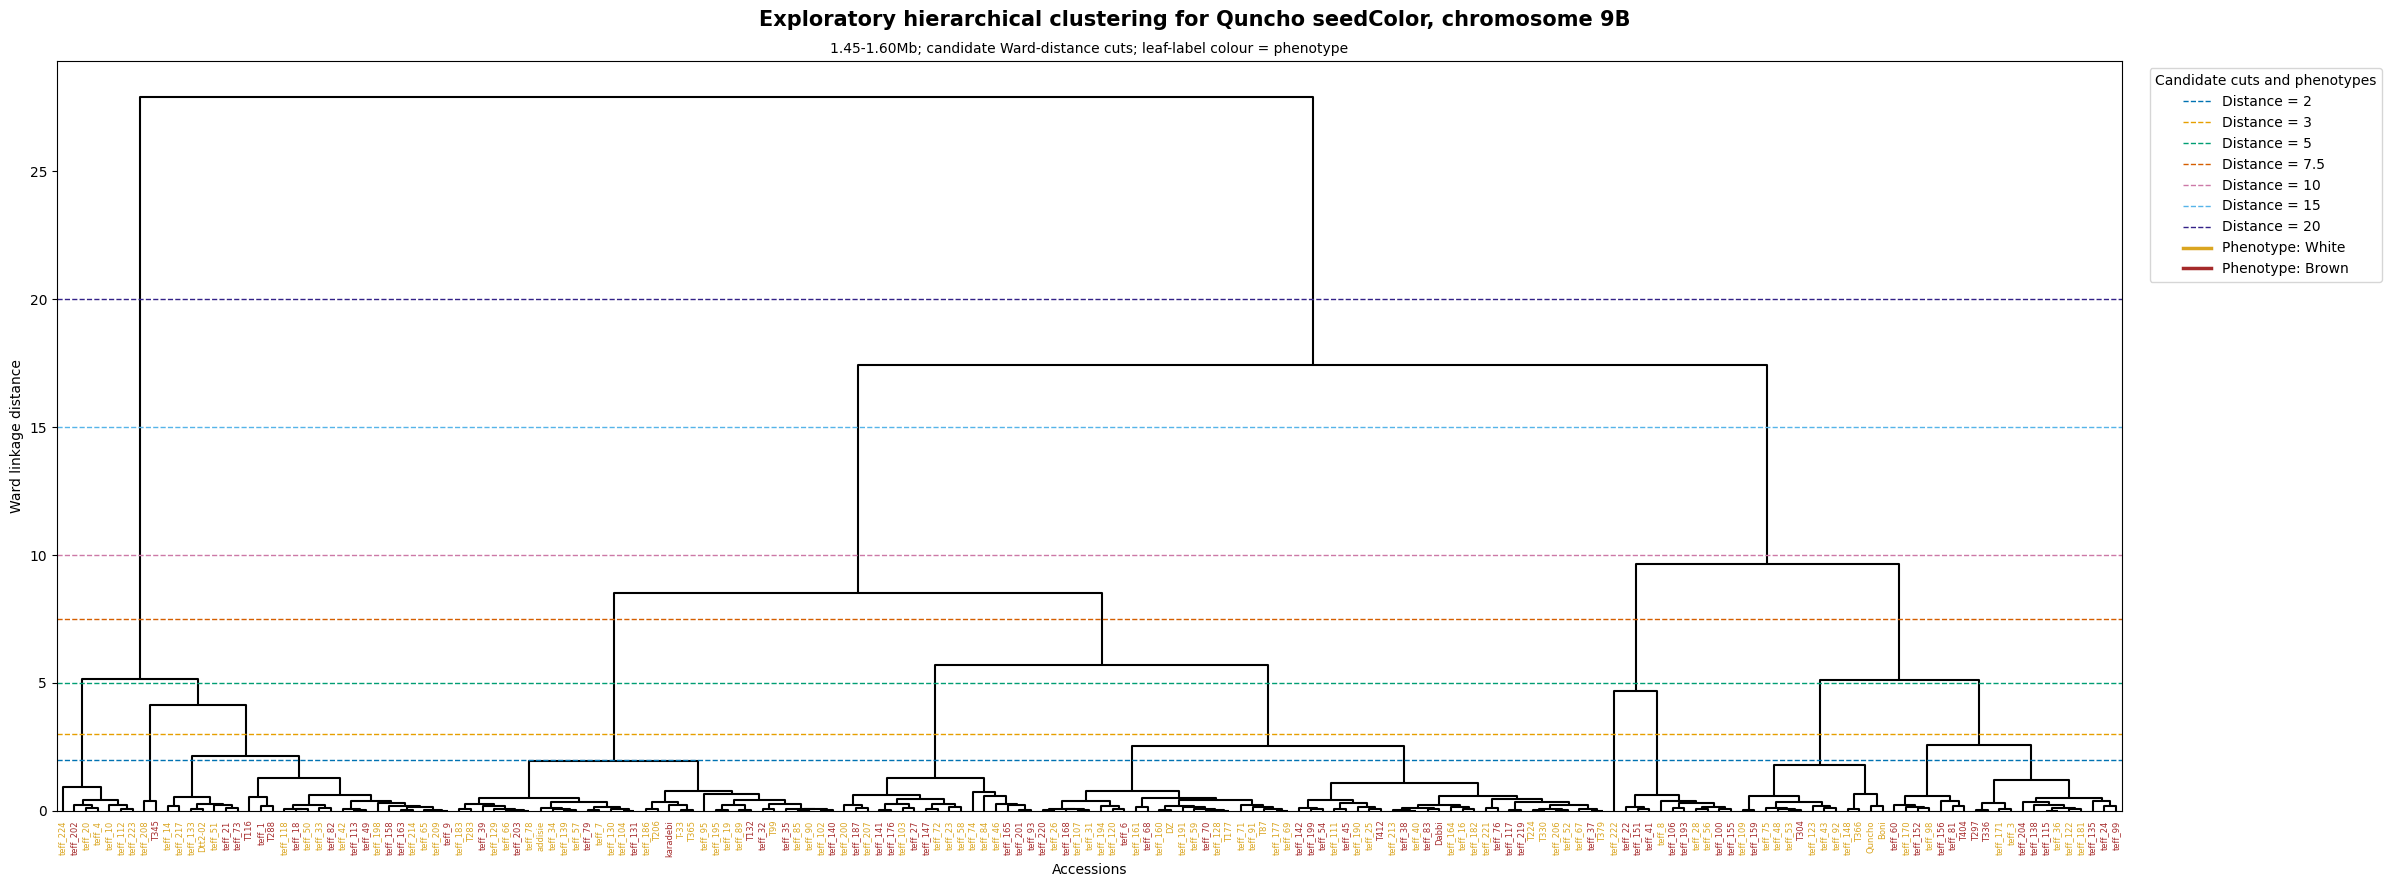

In [250]:
# The linkage matrix has already been calculated using Ward's method.
plt.figure(figsize=(24, 9))

ddata_exploratory = dendrogram(
    linked,
    labels=variation_df.index.astype(str),
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0,
    above_threshold_color="black"
)

ax = plt.gca()

# Colour each accession label by phenotype while leaving the exploratory tree
# black so that the candidate cut lines remain easy to compare.
sample_to_phenotype = df["phenotype"].to_dict()

for label in ax.get_xmajorticklabels():
    accession = label.get_text()
    phenotype = sample_to_phenotype.get(accession, "unknown")
    label.set_color(phenotype_to_label_color[phenotype])

# Add candidate Ward-distance thresholds for visual inspection.
# Modify these values according to the range of the dendrogram.
candidate_thresholds = [2, 3, 5, 7.5, 10, 15, 20]

candidate_line_colours = [
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#D55E00",
    "#CC79A7",
    "#56B4E9",
    "#332288",
]

for threshold, line_colour in zip(
    candidate_thresholds,
    candidate_line_colours
):
    ax.axhline(
        y=threshold,
        color=line_colour,
        linestyle="--",
        linewidth=1,
        label=f"Distance = {threshold}"
    )

phenotypes_present = [
    phenotype
    for phenotype in phenotype_order
    if phenotype in set(df["phenotype"])
]

phenotype_label_handles = [
    Line2D(
        [0],
        [0],
        color=phenotype_to_label_color[phenotype],
        linewidth=2.5,
        label=f"Phenotype: {phenotype}",
    )
    for phenotype in phenotypes_present
]

candidate_handles, candidate_labels = ax.get_legend_handles_labels()

plt.suptitle(
    f"Exploratory hierarchical clustering for "
    f"{genome} {trait}, chromosome {chromosome}",
    fontsize=15,
    weight="bold"
)

plt.title(
    f"{target}; candidate Ward-distance cuts; "
    f"leaf-label colour = phenotype",
    fontsize=10
)

plt.xlabel("Accessions")
plt.ylabel("Ward linkage distance")

plt.legend(
    handles=candidate_handles + phenotype_label_handles,
    labels=candidate_labels + [handle.get_label() for handle in phenotype_label_handles],
    title="Candidate cuts and phenotypes",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        outDir,
        f"{analysis_date}_{genome}_{trait}_{chromosome}_"
        f"{target}_cut_explorDendo.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### SELECT THE FINAL DENDROGRAM CUT

After inspecting the exploratory dendrogram, set the Ward-distance threshold below.  Change it when a different interval requires another biologically and visually appropriate cut.

In [251]:
cut_threshold = 7.5

In [252]:
# =============================================================================
# ASSIGN HAPLOTYPES USING A DENDROGRAM DISTANCE THRESHOLD
# =============================================================================

# Select the Ward linkage distance at which the dendrogram will be cut.
# Change this value after visually inspecting the exploratory dendrogram.

# Assign haplotypes by cutting the hierarchical tree at the selected distance.
haplotypes_raw = fcluster(
    linked,
    t=cut_threshold,
    criterion="distance"
)

# -------------------------------------------------------------------------
# Relabel haplotypes according to their left-to-right order in the dendrogram.
#
# fcluster identifiers are valid but are not necessarily assigned in an
# intuitive visual order. This step makes the leftmost group Haplotype 1,
# followed by Haplotype 2, and so on.
# -------------------------------------------------------------------------

dendro_order = dendrogram(
    linked,
    no_plot=True
)["leaves"]

haplotype_order = []

for leaf_index in dendro_order:
    haplotype_id = haplotypes_raw[leaf_index]

    if haplotype_id not in haplotype_order:
        haplotype_order.append(haplotype_id)

haplotype_relabel_map = {
    old_haplotype: new_haplotype
    for new_haplotype, old_haplotype in enumerate(
        haplotype_order,
        start=1
    )
}

haplotypes = np.array(
    [
        haplotype_relabel_map[haplotype_id]
        for haplotype_id in haplotypes_raw
    ]
)

number_of_haplotypes = len(np.unique(haplotypes))

print(
    f"Cutting the dendrogram at Ward distance {cut_threshold} "
    f"produced {number_of_haplotypes} haplotypes."
)

haplotype_column = f"haplotype-{chromosome}"

# Add the final threshold-derived haplotypes to the results table. The row
# order remains identical to the PCA score matrix.
results_df = df.copy()
results_df[haplotype_column] = haplotypes

print("\nNumber of accessions in each haplotype:")
print(
    results_df[haplotype_column]
    .value_counts()
    .sort_index()
)

print("\nPhenotype composition of each haplotype:")
display(
    pd.crosstab(
        results_df[haplotype_column],
        results_df["phenotype"],
        margins=True
    )
)

Cutting the dendrogram at Ward distance 7.5 produced 5 haplotypes.

Number of accessions in each haplotype:
1    34
2    33
3    66
4    11
5    33
Name: haplotype-9B, dtype: int64

Phenotype composition of each haplotype:


phenotype,Brown,White,All
haplotype-9B,,,
1,14,20,34
2,9,24,33
3,25,41,66
4,7,4,11
5,15,18,33
All,70,107,177


In [253]:
# =============================================================================
# DEFINE HAPLOTYPE BRANCH COLOURS, HAPLOTYPE SHAPES, AND PLOT HELPERS
# =============================================================================

# High-contrast palette used only for haplotype branches in the final
# dendrogram. PCA point colour is reserved for phenotype.
haplotype_branch_colours = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#000000",  # black
    "#332288",  # indigo
    "#661100",  # dark brown
    "#888888",  # grey
    "#44AA99",  # teal
    "#882255",  # wine
    "#117733",  # dark green
    "#999933",  # olive
    "#AA4499",  # purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#88CCEE",  # light blue
    "#DDCC77",  # sand
    "#CC6677",  # muted red
    "#6699CC",  # steel blue
]

if number_of_haplotypes > len(haplotype_branch_colours):
    raise ValueError(
        f"The selected dendrogram cut produced {number_of_haplotypes} "
        f"haplotypes, but the branch palette contains only "
        f"{len(haplotype_branch_colours)} colours."
    )

unique_haplotypes = sorted(np.unique(haplotypes))

haplotype_branch_color_map = {
    haplotype_id: haplotype_branch_colours[i]
    for i, haplotype_id in enumerate(unique_haplotypes)
}

if number_of_haplotypes > len(haplotype_markers):
    print(
        f"Warning: {number_of_haplotypes} haplotypes were inferred but only "
        f"{len(haplotype_markers)} distinct marker shapes are available. "
        "Marker shapes will be reused."
    )

haplotype_to_marker = {
    haplotype_id: haplotype_markers[i % len(haplotype_markers)]
    for i, haplotype_id in enumerate(unique_haplotypes)
}

sample_to_haplotype = dict(
    zip(results_df.index.astype(str), haplotypes)
)

phenotypes = results_df["phenotype"].to_numpy()

phenotypes_present = [
    phenotype
    for phenotype in phenotype_order
    if phenotype in set(phenotypes)
]


def add_phenotype_haplotype_legends(
    ax,
    is_3d=False,
    include_dendrogram_groups=False
):
    """
    Add separate legends for:

    1. Phenotype colours
    2. Haplotype marker shapes
    3. Dendrogram-group outline colours
    """

    # Move legends slightly farther right for 3D figures
    legend_x = 1.15 if is_3d else 1.02

    # ---------------------------------------------------------
    # PHENOTYPE LEGEND: point fill colour
    # ---------------------------------------------------------
    phenotype_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=phenotype_to_color[phenotype],
            markeredgecolor="black",
            markersize=8,
            label=phenotype
        )
        for phenotype in phenotypes_present
    ]

    phenotype_legend = ax.legend(
        handles=phenotype_handles,
        title="Phenotype (colour)",
        bbox_to_anchor=(legend_x, 1.00),
        loc="upper left"
    )

    # Preserve the phenotype legend when subsequent legends are added
    ax.add_artist(phenotype_legend)

    # ---------------------------------------------------------
    # HAPLOTYPE LEGEND: marker shape
    # ---------------------------------------------------------
    haplotype_handles = [
        Line2D(
            [0],
            [0],
            marker=haplotype_to_marker[haplotype_id],
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label=f"Haplotype {haplotype_id}"
        )
        for haplotype_id in unique_haplotypes
    ]

    haplotype_legend = ax.legend(
        handles=haplotype_handles,
        title="Haplotype (shape)",
        bbox_to_anchor=(legend_x, 0.67),
        loc="upper left"
    )

    # Preserve the haplotype legend
    ax.add_artist(haplotype_legend)

    # ---------------------------------------------------------
    # DENDROGRAM-GROUP LEGEND: region outline colour
    # ---------------------------------------------------------
    if include_dendrogram_groups:

        dendrogram_group_handles = [
            Line2D(
                [0],
                [0],
                color=haplotype_branch_color_map[haplotype_id],
                linestyle="--",
                linewidth=2.5,
                label=f"Group {haplotype_id}"
            )
            for haplotype_id in unique_haplotypes
        ]

        dendrogram_legend = ax.legend(
            handles=dendrogram_group_handles,
            title="Dendrogram group (outline)",
            bbox_to_anchor=(legend_x, 0.33),
            loc="upper left"
        )

        ax.add_artist(dendrogram_legend)

def add_complete_pca_legend(ax):
    """
    Add one combined legend containing phenotype colours,
    haplotype shapes, and dendrogram-group outline colours.
    """

    # Phenotype colour handles
    phenotype_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=phenotype_to_color[phenotype],
            markeredgecolor="black",
            markersize=8,
            label=f"Phenotype: {phenotype}"
        )
        for phenotype in phenotypes_present
    ]

    # Haplotype shape handles
    haplotype_handles = [
        Line2D(
            [0],
            [0],
            marker=haplotype_to_marker[haplotype_id],
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label=f"Haplotype shape: {haplotype_id}"
        )
        for haplotype_id in unique_haplotypes
    ]

    # Dendrogram-group outline handles
    dendrogram_handles = [
        Line2D(
            [0],
            [0],
            color=haplotype_branch_color_map[haplotype_id],
            linestyle="--",
            linewidth=2.5,
            label=f"Dendrogram group: {haplotype_id}"
        )
        for haplotype_id in unique_haplotypes
    ]

    # Combine everything into one legend
    all_handles = (
        phenotype_handles
        + haplotype_handles
        + dendrogram_handles
    )

    legend = ax.legend(
        handles=all_handles,
        title="PCA plot encoding",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        frameon=True
    )

    return legend

def scatter_by_phenotype_and_haplotype(ax, x_values, y_values, size=75):
    """Plot 2D PCA scores using colour for phenotype and shape for haplotype."""

    for haplotype_id in unique_haplotypes:
        for phenotype in phenotypes_present:
            point_mask = (
                (haplotypes == haplotype_id)
                & (phenotypes == phenotype)
            )

            if not np.any(point_mask):
                continue

            ax.scatter(
                x_values[point_mask],
                y_values[point_mask],
                color=phenotype_to_color[phenotype],
                marker=haplotype_to_marker[haplotype_id],
                alpha=0.85,
                edgecolor="black",
                linewidth=0.6,
                s=size,
            )

In [254]:
def add_group_ellipse(
    ax,
    group_points,
    group_colour,
    alpha=0.10
):
    """
    Draw an ellipse around a group containing fewer than three
    points or points for which a convex hull cannot be calculated.
    """

    centre = group_points.mean(axis=0)

    x_range = np.ptp(group_points[:, 0])
    y_range = np.ptp(group_points[:, 1])

    # Use the PCA-axis ranges to give very small groups a visible outline
    axis_x_range = np.ptp(ax.get_xlim())
    axis_y_range = np.ptp(ax.get_ylim())

    width = max(x_range * 1.5, axis_x_range * 0.06)
    height = max(y_range * 1.5, axis_y_range * 0.06)

    ellipse = Ellipse(
        xy=centre,
        width=width,
        height=height,
        facecolor=group_colour,
        edgecolor=group_colour,
        linewidth=2,
        linestyle="--",
        alpha=alpha,
        zorder=1
    )

    ax.add_patch(ellipse)

In [255]:
def add_dendrogram_group_outlines(
    ax,
    x_values,
    y_values,
    assignments,
    group_color_map,
    alpha=0.10,
    padding=0.08
):
    """
    Draw a coloured region around samples belonging to each
    dendrogram-derived group.

    Parameters
    ----------
    ax
        Matplotlib axis.

    x_values, y_values
        PCA coordinates for the two displayed components.

    assignments
        Dendrogram-derived haplotype assignment for each sample.

    group_color_map
        Dictionary mapping each haplotype to a colour.

    alpha
        Transparency of the shaded regions.

    padding
        Proportion by which the convex hull is expanded.
    """

    for group_id in sorted(np.unique(assignments)):

        group_mask = assignments == group_id

        group_points = np.column_stack(
            [
                x_values[group_mask],
                y_values[group_mask]
            ]
        )

        group_colour = group_color_map[group_id]

        # Three or more samples: draw a convex hull
        if len(group_points) >= 3:

            try:
                hull = ConvexHull(group_points)
                hull_points = group_points[hull.vertices]

                # Expand the polygon slightly around its centre
                centre = hull_points.mean(axis=0)

                expanded_points = (
                    centre
                    + (hull_points - centre) * (1 + padding)
                )

                polygon = Polygon(
                    expanded_points,
                    closed=True,
                    facecolor=group_colour,
                    edgecolor=group_colour,
                    linewidth=2,
                    linestyle="--",
                    alpha=alpha,
                    zorder=1
                )

                ax.add_patch(polygon)

            except QhullError:
                # Handles collinear points
                add_group_ellipse(
                    ax,
                    group_points,
                    group_colour,
                    alpha
                )

        # One or two samples: use an ellipse instead
        else:
            add_group_ellipse(
                ax,
                group_points,
                group_colour,
                alpha
            )

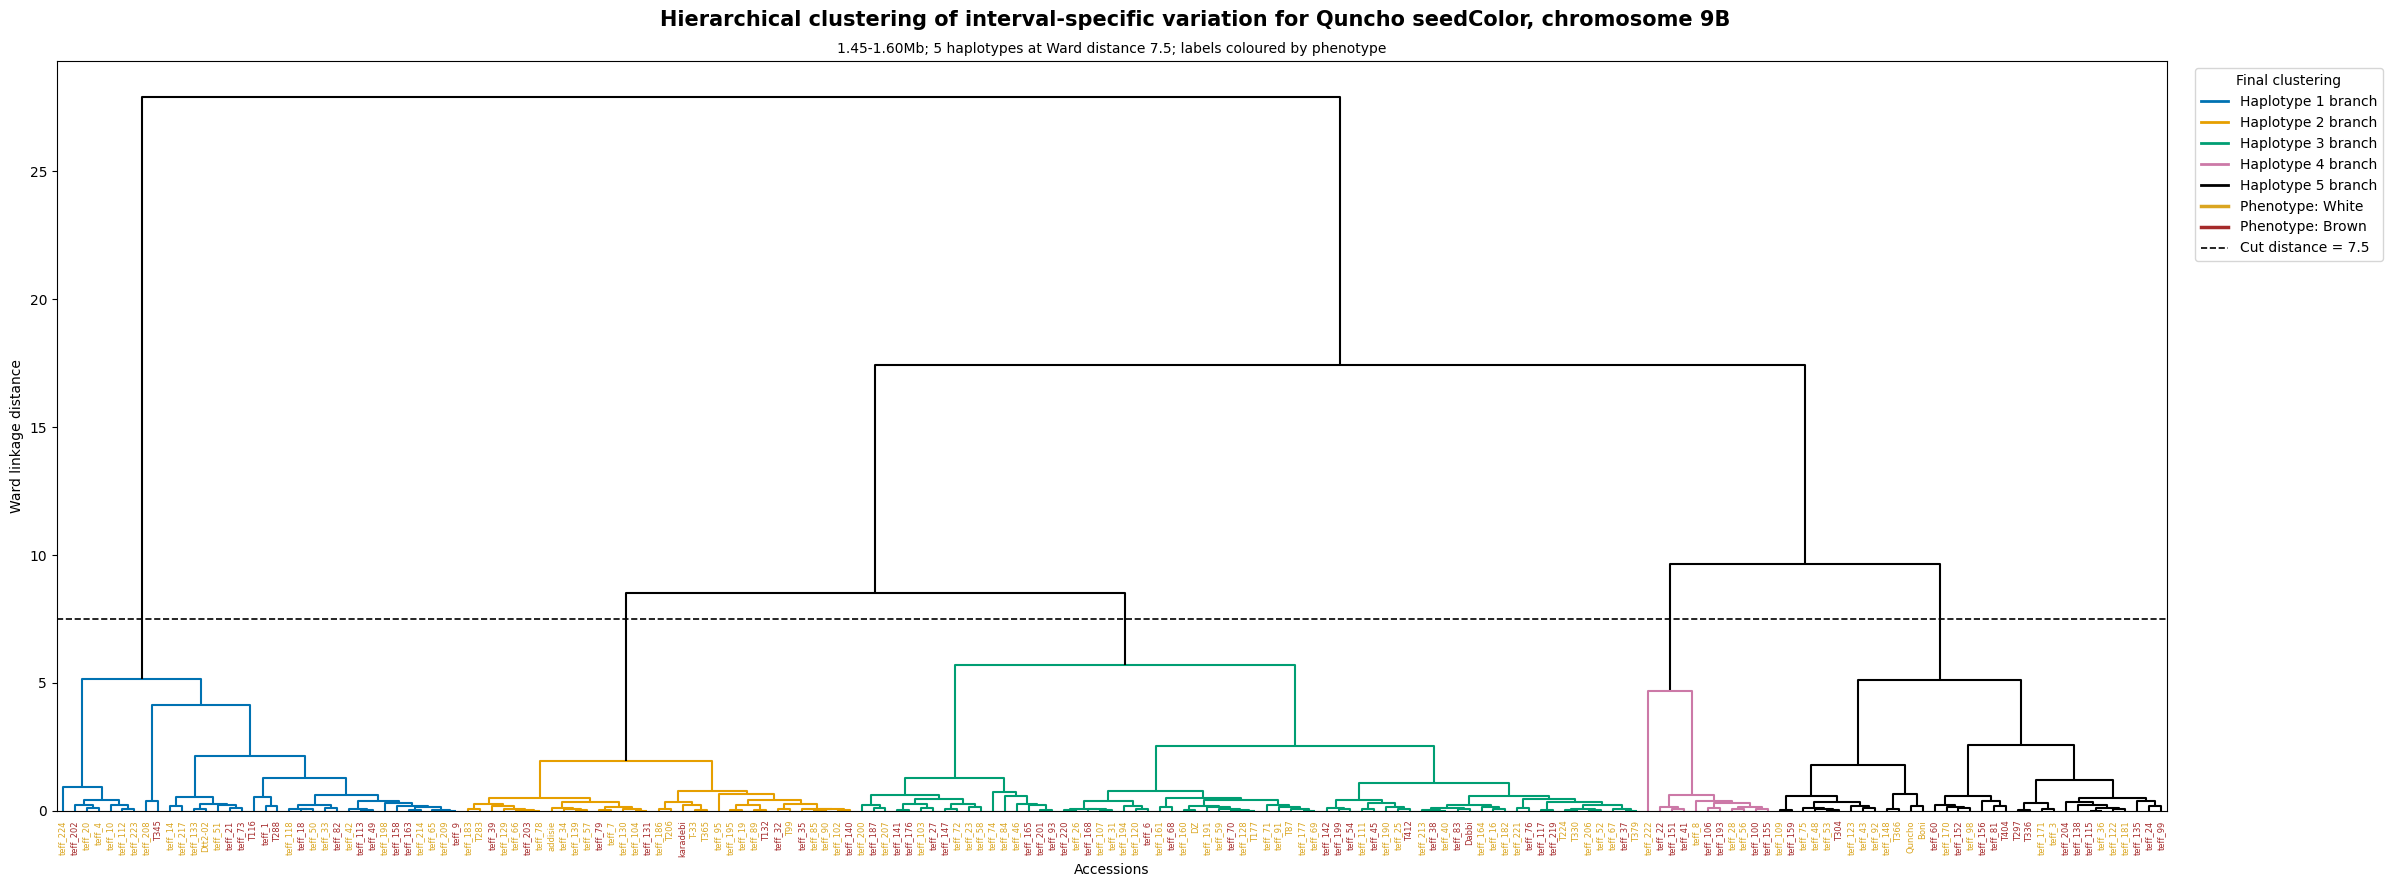

In [256]:
# =============================================================================
# REPLOT THE DENDROGRAM USING THE SELECTED CUT
#
# Branch colour = haplotype
# Leaf-label colour = phenotype
# =============================================================================

number_of_accessions = len(results_df)

# Store the descendant leaves associated with every node in the linkage tree.
descendant_cache = {
    leaf_index: [leaf_index]
    for leaf_index in range(number_of_accessions)
}


def get_descendant_leaves(node_id):
    """Return all original leaf indices descending from a linkage-tree node."""

    node_id = int(node_id)

    if node_id in descendant_cache:
        return descendant_cache[node_id]

    linkage_row = node_id - number_of_accessions

    left_child = int(linked[linkage_row, 0])
    right_child = int(linked[linkage_row, 1])

    descendant_leaves = (
        get_descendant_leaves(left_child)
        + get_descendant_leaves(right_child)
    )

    descendant_cache[node_id] = descendant_leaves
    return descendant_leaves


def dendrogram_branch_colour(node_id):
    """
    Colour a branch by haplotype when all descendant accessions belong to the
    same final haplotype. Mixed-haplotype branches are black.
    """

    descendant_leaves = get_descendant_leaves(node_id)
    descendant_haplotypes = np.unique(haplotypes[descendant_leaves])

    if len(descendant_haplotypes) == 1:
        haplotype_id = int(descendant_haplotypes[0])
        return haplotype_branch_color_map[haplotype_id]

    return "#000000"


plt.figure(figsize=(24, 9))

ddata = dendrogram(
    linked,
    labels=results_df.index.astype(str),
    leaf_rotation=90,
    leaf_font_size=6,
    link_color_func=dendrogram_branch_colour,
    above_threshold_color="black"
)

# Draw the selected dendrogram cut.
plt.axhline(
    y=cut_threshold,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut distance = {cut_threshold}"
)

ax = plt.gca()

# Colour accession labels according to phenotype.
for label in ax.get_xmajorticklabels():
    accession = label.get_text()
    phenotype = sample_to_phenotype.get(accession, "unknown")
    label.set_color(phenotype_to_label_color[phenotype])

# Branch legend: colour represents the inferred haplotype in this dendrogram.
haplotype_branch_handles = [
    Line2D(
        [0],
        [0],
        color=haplotype_branch_color_map[haplotype_id],
        linewidth=2,
        label=f"Haplotype {haplotype_id} branch"
    )
    for haplotype_id in unique_haplotypes
]

phenotype_label_handles = [
    Line2D(
        [0],
        [0],
        color=phenotype_to_label_color[phenotype],
        linewidth=2.5,
        label=f"Phenotype: {phenotype}"
    )
    for phenotype in phenotypes_present
]

cut_line_handle = Line2D(
    [0],
    [0],
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Cut distance = {cut_threshold}"
)

plt.suptitle(
    f"Hierarchical clustering of interval-specific variation for "
    f"{genome} {trait}, chromosome {chromosome}",
    fontsize=15,
    weight="bold"
)

plt.title(
    f"{target}; {number_of_haplotypes} haplotypes at Ward distance "
    f"{cut_threshold}; labels coloured by phenotype",
    fontsize=10
)

plt.xlabel("Accessions")
plt.ylabel("Ward linkage distance")

plt.legend(
    handles=(
        haplotype_branch_handles
        + phenotype_label_handles
        + [cut_line_handle]
    ),
    title="Final clustering",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        outDir,
        f"{analysis_date}_{genome}_{trait}_{chromosome}_"
        f"{target}_dendrogram_cut_{cut_threshold}.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

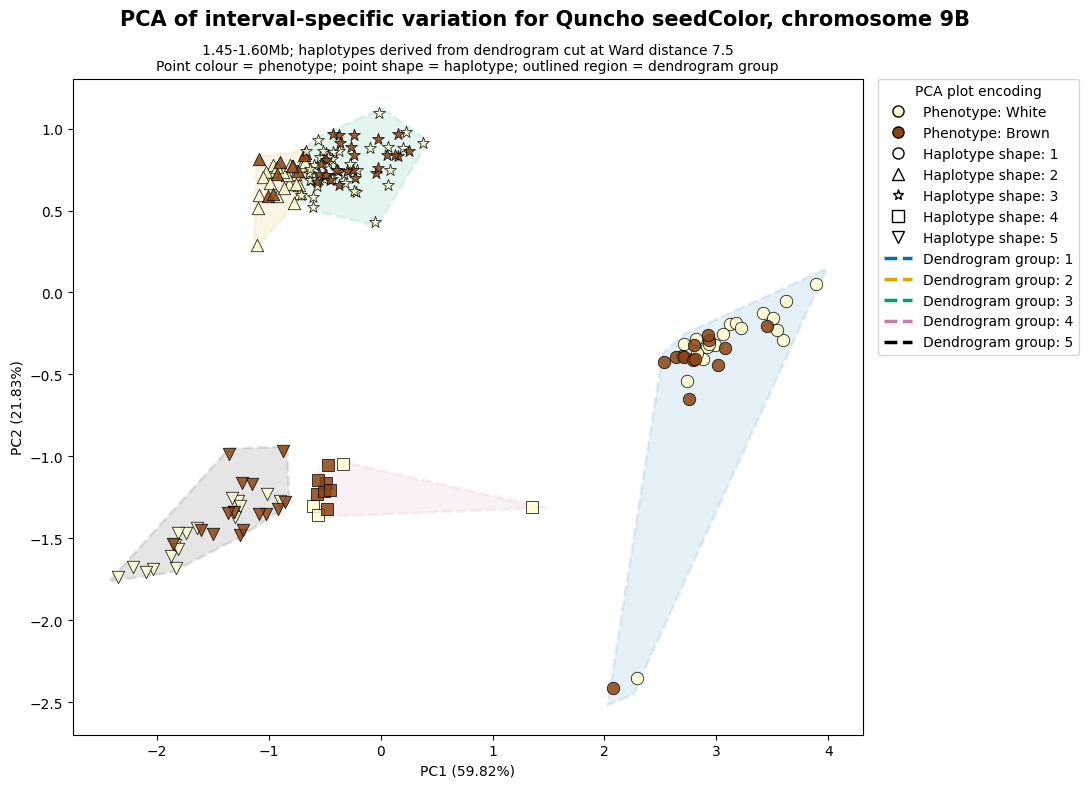

In [257]:
# =============================================================================
# PCA PLOT USING DENDROGRAM-DERIVED HAPLOTYPES
#
# Point colour      = phenotype
# Point shape       = haplotype
# Surrounding region = dendrogram assignment
# =============================================================================

if PCs.shape[1] >= 2:

    fig, ax = plt.subplots(figsize=(11, 8))

    # ---------------------------------------------------------
    # Draw the dendrogram-group regions behind the sample points
    # ---------------------------------------------------------
    add_dendrogram_group_outlines(
        ax=ax,
        x_values=PCs[:, 0],
        y_values=PCs[:, 1],
        assignments=haplotypes,
        group_color_map=haplotype_branch_color_map,
        alpha=0.10,
        padding=0.08
    )

    # ---------------------------------------------------------
    # Plot samples over the dendrogram-group regions
    # Colour = phenotype; shape = haplotype
    # ---------------------------------------------------------
    scatter_by_phenotype_and_haplotype(
        ax=ax,
        x_values=PCs[:, 0],
        y_values=PCs[:, 1],
        size=80
    )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
    )

    plt.suptitle(
        f"PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    ax.set_title(
        f"{target}; haplotypes derived from dendrogram cut at "
        f"Ward distance {cut_threshold}\n"
        f"Point colour = phenotype; point shape = haplotype; "
        f"outlined region = dendrogram group",
        fontsize=10
    )

    legend = add_complete_pca_legend(ax)

    # Leave enough room for the legend
    fig.tight_layout()

    fig.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PCA_cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight",
        bbox_extra_artists=(legend,)
    )

    plt.show()

else:
    print(
        "Fewer than two principal components were retained, so PC1 versus "
        "PC2 cannot be plotted."
    )

###### =============================================================================
#### FUNCTION TO PLOT ANY TWO PRINCIPAL COMPONENTS
###### =============================================================================

The first two principal components may not fully separate the inferred haplotypes. The function below retains the original exploratory comparison of alternative principal-component combinations while using phenotype colours and haplotype shapes consistently.

In [258]:
def plot_pca_pair(
    PCs,
    pca,
    pc_x,
    pc_y,
    genome,
    trait,
    chromosome,
    target,
    cut_threshold,
    outDir,
    analysis_date
):
    """
    Plot any two principal components.

    Point colour = phenotype
    Point shape = haplotype
    Coloured region = dendrogram-derived haplotype group
    """

    # Check that both requested PCs exist
    if PCs.shape[1] <= max(pc_x, pc_y):
        print(
            f"Cannot plot PC{pc_x + 1} against PC{pc_y + 1}: "
            f"only {PCs.shape[1]} principal components were retained."
        )
        return

    # Create the figure for this specific PC combination
    fig, ax = plt.subplots(figsize=(11, 8))

    # ---------------------------------------------------------
    # Add dendrogram-group outlines behind the individual points
    # ---------------------------------------------------------
    add_dendrogram_group_outlines(
        ax=ax,
        x_values=PCs[:, pc_x],
        y_values=PCs[:, pc_y],
        assignments=haplotypes,
        group_color_map=haplotype_branch_color_map,
        alpha=0.10,
        padding=0.08
    )

    # ---------------------------------------------------------
    # Plot individual accessions
    # Colour = phenotype; shape = haplotype
    # ---------------------------------------------------------
    scatter_by_phenotype_and_haplotype(
        ax=ax,
        x_values=PCs[:, pc_x],
        y_values=PCs[:, pc_y],
        size=80
    )

    # Axis labels with explained variance
    ax.set_xlabel(
        f"PC{pc_x + 1} "
        f"({pca.explained_variance_ratio_[pc_x] * 100:.2f}%)"
    )

    ax.set_ylabel(
        f"PC{pc_y + 1} "
        f"({pca.explained_variance_ratio_[pc_y] * 100:.2f}%)"
    )

    plt.suptitle(
        f"PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    ax.set_title(
        f"{target}; Ward-distance cut = {cut_threshold}\n"
        "Point colour = phenotype; marker shape = haplotype; "
        "outlined region = dendrogram group",
        fontsize=10
    )

    legend = add_complete_pca_legend(ax)

    fig.tight_layout()

    fig.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PC{pc_x + 1}_PC{pc_y + 1}_"
            f"cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight",
        bbox_extra_artists=(legend,)
    )

    plt.show()

In [259]:
# =============================================================================
# VERIFY AND SUMMARISE THE FINAL HAPLOTYPE ASSIGNMENTS
# =============================================================================

# Recalculate the distance-threshold groups as a consistency check.
verification_raw = fcluster(
    linked,
    t=cut_threshold,
    criterion="distance"
)

verification_order = []

for leaf_index in dendro_order:
    haplotype_id = verification_raw[leaf_index]

    if haplotype_id not in verification_order:
        verification_order.append(haplotype_id)

verification_map = {
    old_haplotype: new_haplotype
    for new_haplotype, old_haplotype in enumerate(
        verification_order,
        start=1
    )
}

verified_haplotypes = np.array(
    [verification_map[haplotype_id] for haplotype_id in verification_raw]
)

if not np.array_equal(haplotypes, verified_haplotypes):
    raise RuntimeError(
        "The repeated dendrogram cut did not reproduce the stored "
        "haplotype assignments."
    )

unique_haplotypes = sorted(np.unique(haplotypes))
number_of_haplotypes = len(unique_haplotypes)

print(f"Unique haplotypes: {unique_haplotypes}")
print(f"Number of haplotypes: {number_of_haplotypes}")

Unique haplotypes: [1, 2, 3, 4, 5]
Number of haplotypes: 5


In [260]:
# Display the phenotype colours and haplotype marker shapes used in all PCA
# projections.
print("Phenotype colour assignments:")
for phenotype in phenotypes_present:
    print(f"  {phenotype}: {phenotype_to_color[phenotype]}")

print("\nHaplotype marker assignments:")
for haplotype_id in unique_haplotypes:
    print(f"  Haplotype {haplotype_id}: {haplotype_to_marker[haplotype_id]}")

Phenotype colour assignments:
  White: #FFFDD0
  Brown: saddlebrown

Haplotype marker assignments:
  Haplotype 1: o
  Haplotype 2: ^
  Haplotype 3: *
  Haplotype 4: s
  Haplotype 5: v


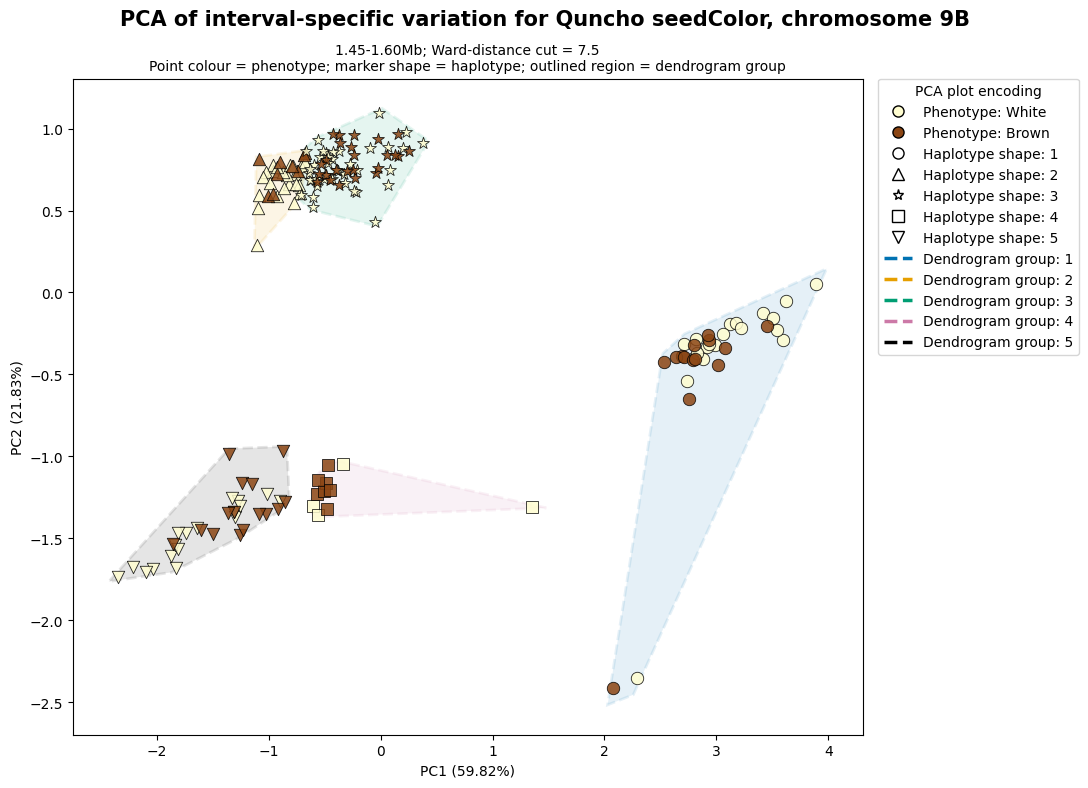

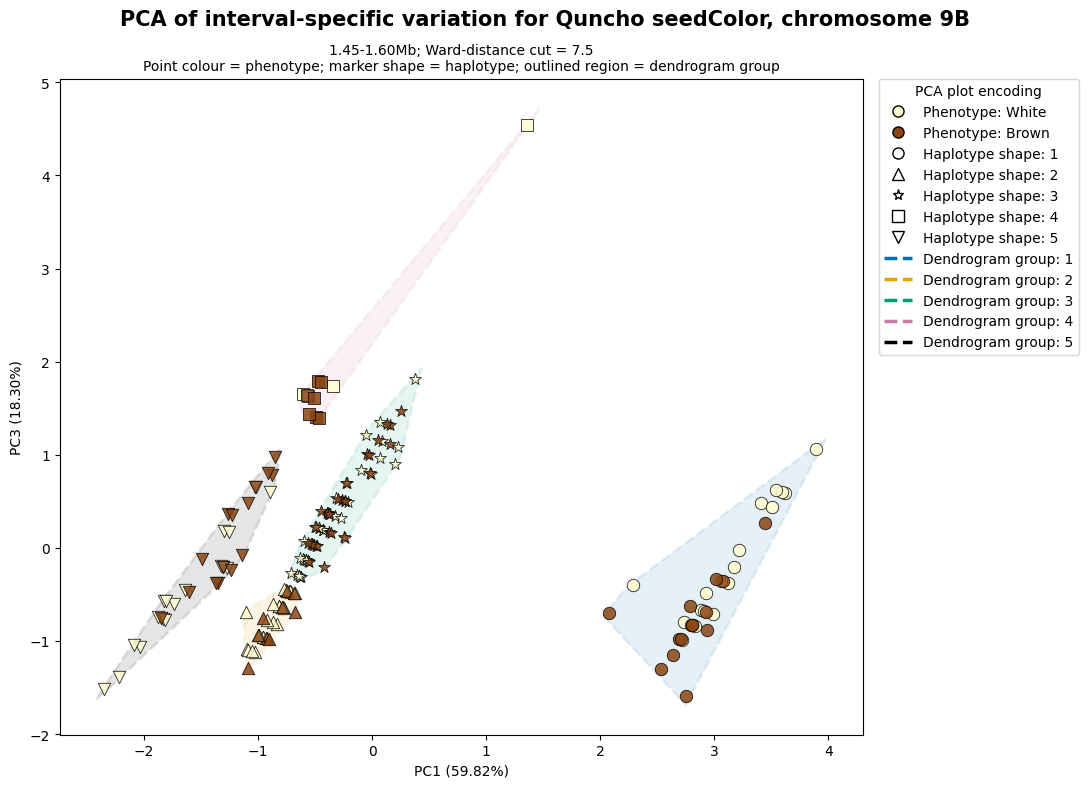

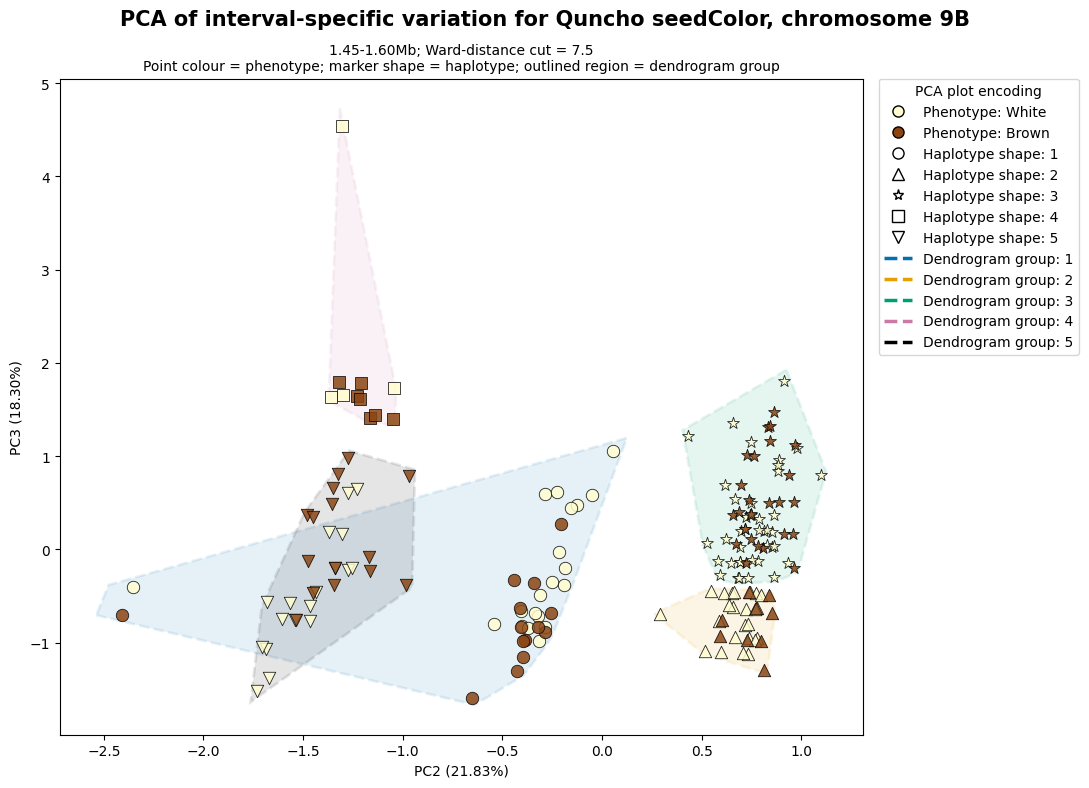

In [261]:

# PC1 versus PC2
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    pc_x=0,
    pc_y=1,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

# PC1 versus PC3
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    pc_x=0,
    pc_y=2,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

# PC2 versus PC3
plot_pca_pair(
    PCs=PCs,
    pca=pca,
    pc_x=1,
    pc_y=2,
    genome=genome,
    trait=trait,
    chromosome=chromosome,
    target=target,
    cut_threshold=cut_threshold,
    outDir=outDir,
    analysis_date=analysis_date
)

###### =============================================================================
##### 3D PCA PLOT: PC1 vs PC2 vs PC3
###### =============================================================================

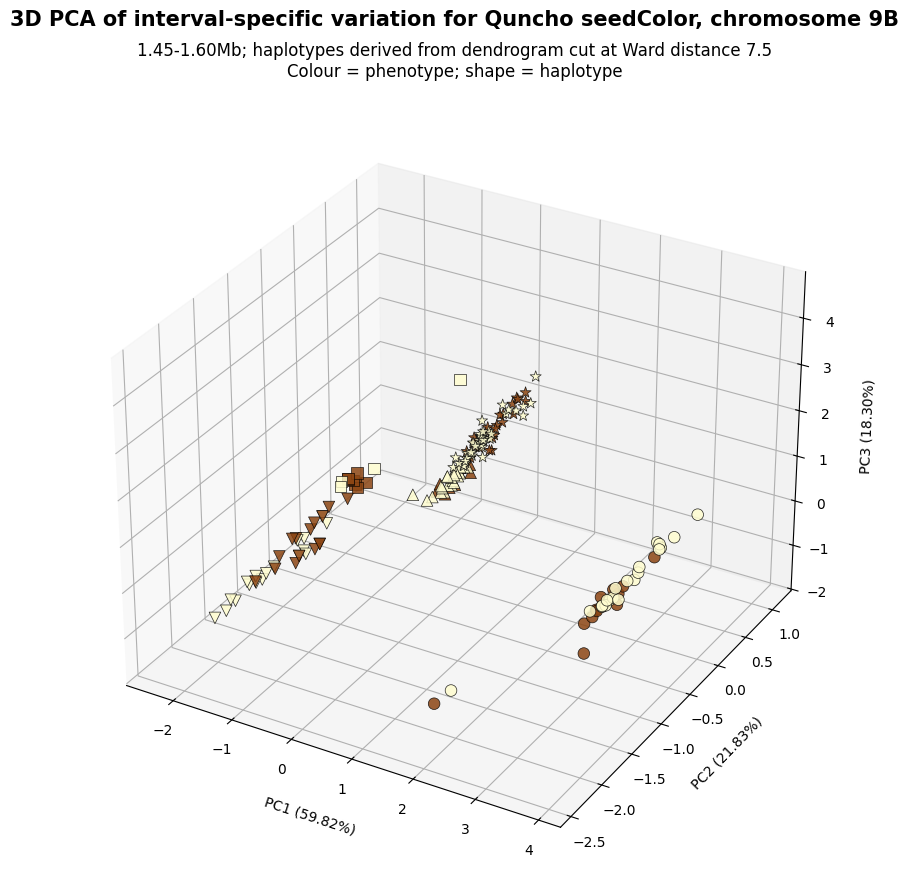

In [262]:
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting in older Matplotlib versions

# Check that at least three principal components were retained.
if PCs.shape[1] >= 3:

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    for haplotype_id in unique_haplotypes:
        for phenotype in phenotypes_present:
            point_mask = (
                (haplotypes == haplotype_id)
                & (phenotypes == phenotype)
            )

            if not np.any(point_mask):
                continue

            ax.scatter(
                PCs[point_mask, 0],
                PCs[point_mask, 1],
                PCs[point_mask, 2],
                color=phenotype_to_color[phenotype],
                marker=haplotype_to_marker[haplotype_id],
                edgecolor="black",
                linewidth=0.5,
                s=70,
                alpha=0.85,
            )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)",
        labelpad=10
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)",
        labelpad=10
    )
    ax.set_zlabel(
        f"PC3 ({pca.explained_variance_ratio_[2] * 100:.2f}%)",
        labelpad=10
    )

    plt.suptitle(
        f"3D PCA of interval-specific variation for "
        f"{genome} {trait}, chromosome {chromosome}",
        fontsize=15,
        weight="bold"
    )

    ax.set_title(
        f"{target}; haplotypes derived from dendrogram cut at "
        f"Ward distance {cut_threshold}\n"
        f"Colour = phenotype; shape = haplotype",
        pad=20
    )

    add_phenotype_haplotype_legends(
    ax,
    is_3d=True,
    include_dendrogram_groups=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            outDir,
            f"{analysis_date}_{genome}_{trait}_{chromosome}_"
            f"{target}_PC1_PC2_PC3_3D_cut_{cut_threshold}.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "Fewer than three principal components were retained, "
        "so a 3D PCA plot cannot be generated."
    )

###### =============================================================================
##### SAVE ACCESSION PHENOTYPE AND HAPLOTYPE ASSIGNMENTS
###### =============================================================================

Two interval-level tables are saved:

1. a concise accession, phenotype, and haplotype assignment table for downstream combination; and
2. the full input variation table with phenotype and haplotype annotations.

In [263]:
# Create a concise table containing one row per accession.
haplotype_assignments = pd.DataFrame(
    {
        "Name": results_df.index.astype(str),
        "phenotype": results_df["phenotype"].to_numpy(),
        "reference": genome,
        "trait": trait,
        "chromosome": chromosome,
        "start": start_pos,
        "end": end_pos,
        "analysis_start": analysis_start,
        "analysis_end": analysis_end,
        "cut_threshold": cut_threshold,
        "haplotype": haplotypes,
    }
)

# Sort first by haplotype and then by accession name.
haplotype_assignments = haplotype_assignments.sort_values(
    by=["haplotype", "Name"]
).reset_index(drop=True)

# Define the concise output filename.
haplotype_assignment_file = os.path.join(
    outDir,
    f"{genome}_{trait}_{chromosome}_"
    f"{start_pos}_{end_pos}_"
    f"cut{cut_threshold}_haplotype_assignments.xlsx"
)

haplotype_assignments.to_excel(
    haplotype_assignment_file,
    index=False
)

# Also save the full interval variation table with phenotype and haplotype.
full_results_file = os.path.join(
    outDir,
    f"{genome}_{trait}_{chromosome}_"
    f"{start_pos}_{end_pos}_"
    f"cut{cut_threshold}_variation_phenotype_haplotypes.xlsx"
)

results_df.to_excel(
    full_results_file,
    index=True,
    index_label="Name"
)

print(
    f"Haplotype assignments saved to:\n{haplotype_assignment_file}"
)
print(
    f"\nAnnotated variation table saved to:\n{full_results_file}"
)

Haplotype assignments saved to:
/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-9B-1479311-1599456-Pheno/Quncho_seedColor_9B_1479311_1599456_cut7.5_haplotype_assignments.xlsx

Annotated variation table saved to:
/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-9B-1479311-1599456-Pheno/Quncho_seedColor_9B_1479311_1599456_cut7.5_variation_phenotype_haplotypes.xlsx


###### =============================================================================
##### COMBINE HAPLOTYPE ASSIGNMENTS ACROSS INTERVALS
###### =============================================================================

This section retains the cross-interval analysis from the original workflow. It combines interval-specific haplotypes for a selected reference genome and trait while keeping one verified phenotype column per accession.

In [264]:
# Genome and trait to combine. Update these values as required.
target_genome = "Quncho"
target_trait = "seedColor"

# All interval-specific output directories for this genome are located here.
genome_dir = os.path.join(
    workDir,
    target_genome
)

if not os.path.isdir(genome_dir):
    raise FileNotFoundError(
        f"Genome directory does not exist: {genome_dir}"
    )

# Recursively locate the new phenotype-aware haplotype-assignment files.
haplotype_files = sorted(
    glob.glob(
        os.path.join(
            genome_dir,
            "**",
            "*haplotype_assignments.xlsx"
        ),
        recursive=True
    )
)

print(
    f"Found {len(haplotype_files)} potential haplotype-assignment files "
    f"under: {genome_dir}"
)

Found 12 potential haplotype-assignment files under: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho


In [265]:
# Store the interval-specific tables before combining them.
interval_tables = []

# Track interval identifiers to prevent the same interval being added twice.
used_interval_names = set()

# Retain a single phenotype per accession and check that it is consistent
# across all interval files.
combined_phenotype_by_accession = {}


for haplotype_file in haplotype_files:

    print(f"\nChecking: {haplotype_file}")

    # Read the haplotype-assignment table.
    haplotype_df = pd.read_excel(haplotype_file)

    # Standardise column names.
    haplotype_df.columns = (
        haplotype_df.columns
        .astype(str)
        .str.strip()
    )

    # Confirm that the required columns are available.
    required_columns = {
        "Name",
        "phenotype",
        "reference",
        "trait",
        "chromosome",
        "start",
        "end",
        "haplotype",
    }

    missing_columns = required_columns.difference(
        haplotype_df.columns
    )

    if missing_columns:
        print(
            f"Skipping file because it is missing columns: "
            f"{sorted(missing_columns)}"
        )
        continue

    # Standardise text columns before filtering.
    for column in [
        "Name",
        "phenotype",
        "reference",
        "trait",
        "chromosome",
    ]:
        haplotype_df[column] = (
            haplotype_df[column]
            .astype(str)
            .str.strip()
        )

    # Retain only records corresponding to the requested genome and trait.
    selected = haplotype_df[
        (haplotype_df["reference"] == target_genome)
        & (haplotype_df["trait"] == target_trait)
    ].copy()

    if selected.empty:
        print(
            f"Skipping file because it does not contain "
            f"{target_genome}, {target_trait}."
        )
        continue

    # Confirm that the current file contains one interval only.
    interval_metadata = (
        selected[
            [
                "chromosome",
                "start",
                "end",
            ]
        ]
        .drop_duplicates()
    )

    if len(interval_metadata) != 1:
        raise ValueError(
            f"Expected one interval in {haplotype_file}, "
            f"but found {len(interval_metadata)}."
        )

    interval_chromosome = str(
        interval_metadata.iloc[0]["chromosome"]
    )

    interval_start = int(
        interval_metadata.iloc[0]["start"]
    )

    interval_end = int(
        interval_metadata.iloc[0]["end"]
    )

    # Include the coordinates because the same chromosome may contain more
    # than one trait-associated interval.
    interval_name = (
        f"{interval_chromosome}_{interval_start}_{interval_end}"
    )

    # Prevent duplicate interval columns.
    if interval_name in used_interval_names:
        raise ValueError(
            f"Duplicate interval detected: {interval_name}\n"
            f"File: {haplotype_file}"
        )

    used_interval_names.add(interval_name)

    # Confirm that every accession occurs only once in the interval.
    duplicated_accessions = selected.loc[
        selected["Name"].duplicated(),
        "Name"
    ].unique()

    if len(duplicated_accessions) > 0:
        raise ValueError(
            f"Duplicate accessions in {haplotype_file}: "
            + ", ".join(duplicated_accessions)
        )

    # Check phenotype consistency across intervals.
    for accession, phenotype in selected[["Name", "phenotype"]].itertuples(
        index=False,
        name=None
    ):
        previous_phenotype = combined_phenotype_by_accession.get(accession)

        if previous_phenotype is not None and previous_phenotype != phenotype:
            raise ValueError(
                f"Conflicting phenotypes were found for {accession}: "
                f"'{previous_phenotype}' and '{phenotype}'."
            )

        combined_phenotype_by_accession[accession] = phenotype

    # Retain accession names and haplotype assignments.
    interval_df = selected[
        [
            "Name",
            "haplotype",
        ]
    ].copy()

    # Rename the haplotype column using the chromosome interval.
    interval_df = interval_df.rename(
        columns={
            "haplotype": interval_name
        }
    )

    # Use accession identifiers as the index for combining tables.
    interval_df = interval_df.set_index("Name")
    interval_tables.append(interval_df)

    print(
        f"Added {interval_name}: "
        f"{len(interval_df)} accessions"
    )

# Stop if no matching files were found.
if not interval_tables:
    raise ValueError(
        f"No matching haplotype-assignment tables were found for "
        f"genome '{target_genome}' and trait '{target_trait}' "
        f"under {genome_dir}."
    )


Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-1B-7735642-8507840-Pheno/Quncho_seedColor_1B_7735642_8507840_cut15_haplotype_assignments.xlsx
Added 1B_7735642_8507840: 177 accessions

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-2A-7531007-7758119-Pheno/Quncho_seedColor_2A_7531007_7758119_cut10_haplotype_assignments.xlsx
Added 2A_7531007_7758119: 177 accessions

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-2B-7380143-7475544-Pheno/Quncho_seedColor_2B_7380143_7475544_cut5_haplotype_assignments.xlsx
Added 2B_7380143_7475544: 177 accessions

Checking: /Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho/Quncho-seedColor-3B-7048571-7068769-Pheno/Quncho_seedColor_3B_7048571_7068769_cut5_haplotype_assignments.xlsx
Added 3B_7048571_7068769: 177 accessions

Checking: /Users/waweru/Documents/202

In [266]:
# =============================================================================
# COMBINE THE INTERVAL TABLES
# =============================================================================

# Use an outer join so that all accessions are retained even when an accession
# is absent from one interval.
combined_haplotypes = pd.concat(
    interval_tables,
    axis=1,
    join="outer"
)

# Sort accession identifiers alphabetically and return the index to a column.
combined_haplotypes = (
    combined_haplotypes
    .sort_index()
    .reset_index()
)

# Ensure the accession column is explicitly named "Name".
combined_haplotypes = combined_haplotypes.rename(
    columns={
        combined_haplotypes.columns[0]: "Name"
    }
)

# Insert one phenotype column immediately after accession name.
combined_haplotypes.insert(
    1,
    "phenotype",
    combined_haplotypes["Name"]
    .map(combined_phenotype_by_accession)
    .fillna("unknown")
)

In [267]:
display(combined_haplotypes.head())

,Name,phenotype,1B_7735642_8507840,2A_7531007_7758119,2B_7380143_7475544,3B_7048571_7068769,4A_14530517_15856068,4B_12734841_13821040,4B_13161163_14016328,5A_26141158_26300646,6A_1351898_1393168,6A_24243902_24470312,9A_23018638_23158676,9B_1479311_1599456
0,Boni,White,1,3,3,3,2,4,4,5,2,4,6,5
1,DZ,White,1,6,3,4,6,1,1,1,2,5,7,3
2,Dabbi,Brown,1,4,3,3,6,6,3,5,2,5,2,3
3,Dtt2-02,White,1,3,3,4,6,4,4,5,2,4,7,1
4,Quncho,White,3,5,4,3,1,1,1,1,2,4,7,5


In [268]:
# =============================================================================
# SAVE THE COMBINED PHENOTYPE AND HAPLOTYPE TABLE
# =============================================================================

combined_output_file = os.path.join(
    workDir,
    f"{target_genome}_{target_trait}_"
    f"combined_haplotype_assignments_withPhenoDat.xlsx"
)

combined_haplotypes.to_excel(
    combined_output_file,
    index=False
)

print(
    f"\nCombined haplotype-assignment table saved to:\n"
    f"{combined_output_file}"
)

print(
    f"\nCombined table contains "
    f"{combined_haplotypes.shape[0]} accessions and "
    f"{combined_haplotypes.shape[1] - 2} intervals, plus phenotype."
)

display(combined_haplotypes.head())


Combined haplotype-assignment table saved to:
/Users/waweru/Documents/2022/2025-10-TeffPangenomics/2026-JuneAnalysis/Quncho_seedColor_combined_haplotype_assignments_withPhenoDat.xlsx

Combined table contains 177 accessions and 12 intervals, plus phenotype.


,Name,phenotype,1B_7735642_8507840,2A_7531007_7758119,2B_7380143_7475544,3B_7048571_7068769,4A_14530517_15856068,4B_12734841_13821040,4B_13161163_14016328,5A_26141158_26300646,6A_1351898_1393168,6A_24243902_24470312,9A_23018638_23158676,9B_1479311_1599456
0,Boni,White,1,3,3,3,2,4,4,5,2,4,6,5
1,DZ,White,1,6,3,4,6,1,1,1,2,5,7,3
2,Dabbi,Brown,1,4,3,3,6,6,3,5,2,5,2,3
3,Dtt2-02,White,1,3,3,4,6,4,4,5,2,4,7,1
4,Quncho,White,3,5,4,3,1,1,1,1,2,4,7,5
